In [ ]:
#  Air Quality Data Science Project

### Real-World Environmental Data Analysis & Pollution Prediction Using Python

**Objective:**  
Analyze real-world air quality measurements, identify pollution patterns,
study relationships between pollutants and environmental conditions,
and develop a data-driven prediction model.

**Dataset:** UCI Air Quality Dataset  
**Tools:** Python • Pandas • NumPy • Matplotlib • Seaborn • Scikit-learn  
**Environment:** Jupyter Notebook

---

### Project Workflow

`Raw Data → Data Cleaning → Data Quality → EDA → Statistical Insights → 
Feature Engineering → Machine Learning → Model Evaluation → 
Interpretation → Strategic Recommendations`

**Developed as part of a Data Science with Python Internship**

In [1]:
# Core data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Visualization settings
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
from pathlib import Path

# Documents folder
documents_path = Path.home() / "Documents"

# Original dataset
file_path = documents_path / "AirQualityUCI.csv"

# Load dataset
df_raw = pd.read_csv(
    file_path,
    sep=";",
    decimal=","
)

print("Dataset loaded successfully!")
print("File:", file_path)
print("Shape:", df_raw.shape)

Dataset loaded successfully!
File: C:\Users\rohan bhowmik\Documents\AirQualityUCI.csv
Shape: (9471, 17)


In [3]:
# Create a working copy
df = df_raw.copy()

print("Raw dataset preserved.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Raw dataset preserved.
Rows: 9,471
Columns: 17


In [4]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [5]:
df.tail()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
9466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9470,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(15), object(2)
memory usage: 1.2+ MB


In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,9357,391,03/04/2005,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Time,9357,24,18.00.00,390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CO(GT),9357.0,NaN,NaN,NaN,-34.207524,77.65717,-200.0,0.6,1.5,2.6,11.9
PT08.S1(CO),9357.0,NaN,NaN,NaN,1048.990061,329.83271,-200.0,921.0,1053.0,1221.0,2040.0
NMHC(GT),9357.0,NaN,NaN,NaN,-159.090093,139.789093,-200.0,-200.0,-200.0,-200.0,1189.0
C6H6(GT),9357.0,NaN,NaN,NaN,1.865683,41.380206,-200.0,4.0,7.9,13.6,63.7
PT08.S2(NMHC),9357.0,NaN,NaN,NaN,894.595276,342.333252,-200.0,711.0,895.0,1105.0,2214.0
NOx(GT),9357.0,NaN,NaN,NaN,168.616971,257.433866,-200.0,50.0,141.0,284.0,1479.0
PT08.S3(NOx),9357.0,NaN,NaN,NaN,794.990168,321.993552,-200.0,637.0,794.0,960.0,2683.0
NO2(GT),9357.0,NaN,NaN,NaN,58.148873,126.940455,-200.0,53.0,96.0,133.0,340.0


In [ ]:
##  Data Quality Assessment

Before performing statistical analysis or machine learning, the dataset
must be evaluated for:

- Missing values
- Invalid measurements
- Duplicate records
- Incorrect data types
- Inconsistent timestamps
- Potential outliers

The original UCI Air Quality dataset uses `-200` to represent missing
sensor measurements. These values must therefore be treated as missing
rather than as genuine pollution measurements.

In [8]:
# Check missing values
missing_before = df.isnull().sum()

missing_before[missing_before > 0].sort_values(ascending=False)

Unnamed: 16      9471
Unnamed: 15      9471
Date              114
Time              114
CO(GT)            114
C6H6(GT)          114
PT08.S2(NMHC)     114
PT08.S1(CO)       114
NMHC(GT)          114
PT08.S3(NOx)      114
NOx(GT)           114
NO2(GT)           114
PT08.S4(NO2)      114
T                 114
PT08.S5(O3)       114
AH                114
RH                114
dtype: int64

In [9]:
# Remove columns that contain no information
df = df.dropna(axis=1, how="all")

print("Shape after removing completely empty columns:", df.shape)

Shape after removing completely empty columns: (9471, 15)


In [10]:
df.columns = [
    "Date",
    "Time",
    "CO",
    "PT08_S1_CO",
    "NMHC",
    "C6H6",
    "PT08_S2_NMHC",
    "NOx",
    "PT08_S3_NOx",
    "NO2",
    "PT08_S4_NO2",
    "PT08_S5_O3",
    "Temperature",
    "Relative_Humidity",
    "Absolute_Humidity"
]

df.columns

Index(['Date', 'Time', 'CO', 'PT08_S1_CO', 'NMHC', 'C6H6', 'PT08_S2_NMHC',
       'NOx', 'PT08_S3_NOx', 'NO2', 'PT08_S4_NO2', 'PT08_S5_O3', 'Temperature',
       'Relative_Humidity', 'Absolute_Humidity'],
      dtype='object')

In [11]:
# Count invalid sensor values
invalid_counts = (df == -200).sum()

invalid_counts[invalid_counts > 0].sort_values(ascending=False)

NMHC                 8443
CO                   1683
NO2                  1642
NOx                  1639
PT08_S1_CO            366
PT08_S2_NMHC          366
C6H6                  366
PT08_S3_NOx           366
PT08_S4_NO2           366
PT08_S5_O3            366
Temperature           366
Relative_Humidity     366
Absolute_Humidity     366
dtype: int64

In [12]:
# Replace UCI missing-value marker with NaN
df = df.replace(-200, np.nan)

print("Invalid -200 values converted to NaN.")

Invalid -200 values converted to NaN.


In [13]:
df["DateTime"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str),
    format="%d/%m/%Y %H.%M.%S",
    errors="coerce"
)

print("DateTime column created.")
df[["Date", "Time", "DateTime"]].head()

DateTime column created.


,Date,Time,DateTime
0,10/03/2004,18.00.00,2004-03-10 18:00:00
1,10/03/2004,19.00.00,2004-03-10 19:00:00
2,10/03/2004,20.00.00,2004-03-10 20:00:00
3,10/03/2004,21.00.00,2004-03-10 21:00:00
4,10/03/2004,22.00.00,2004-03-10 22:00:00


In [14]:
numeric_columns = [
    "CO",
    "PT08_S1_CO",
    "NMHC",
    "C6H6",
    "PT08_S2_NMHC",
    "NOx",
    "PT08_S3_NOx",
    "NO2",
    "PT08_S4_NO2",
    "PT08_S5_O3",
    "Temperature",
    "Relative_Humidity",
    "Absolute_Humidity"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

print("Numeric columns converted successfully.")

Numeric columns converted successfully.


In [15]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count:,}")

Duplicate rows: 113


In [16]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count:,}")

Duplicate rows: 113


In [17]:
df = df.sort_values("DateTime").reset_index(drop=True)

print("Dataset sorted chronologically.")
df[["DateTime", "CO", "NOx", "NO2"]].head()

Dataset sorted chronologically.


,DateTime,CO,NOx,NO2
0,2004-03-10 18:00:00,2.6,166.0,113.0
1,2004-03-10 19:00:00,2.0,103.0,92.0
2,2004-03-10 20:00:00,2.2,131.0,114.0
3,2004-03-10 21:00:00,2.2,172.0,122.0
4,2004-03-10 22:00:00,1.6,131.0,116.0


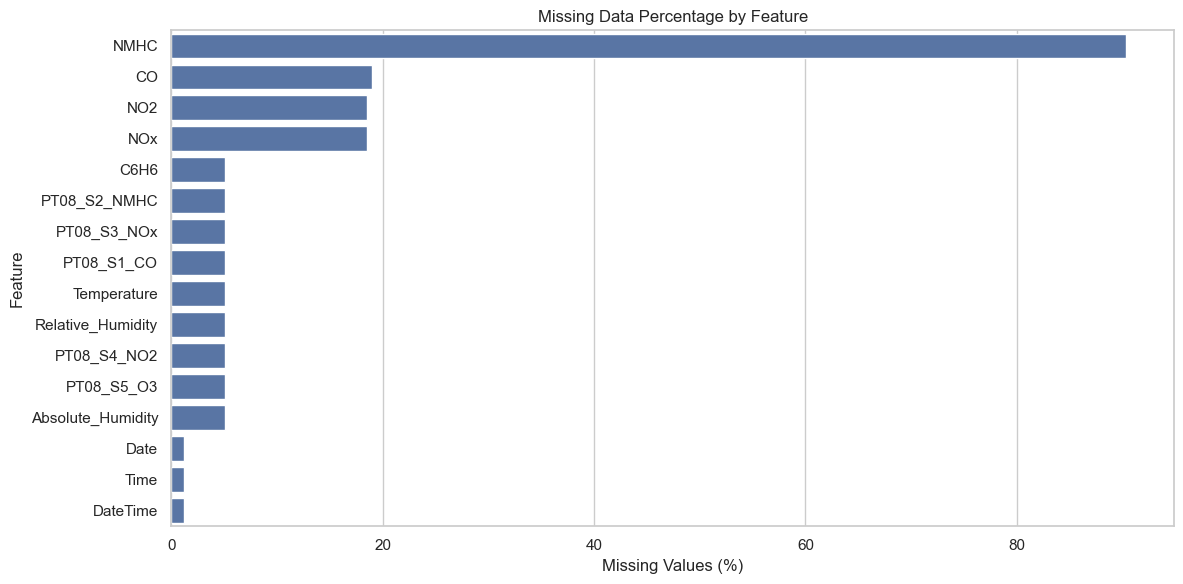

In [18]:
missing_percentage = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percentage = missing_percentage[
    missing_percentage > 0
]

plt.figure(figsize=(12, 6))

sns.barplot(
    x=missing_percentage.values,
    y=missing_percentage.index
)

plt.title("Missing Data Percentage by Feature")
plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
##  Missing Data Treatment Strategy

Sensor-based environmental datasets commonly contain missing observations.

Instead of replacing missing values with arbitrary constants, this project
uses time-aware interpolation for continuous measurements. This preserves
the temporal structure of the data and provides more meaningful estimates
between neighboring observations.

The original raw dataset remains preserved separately, while the cleaned
dataset is used for downstream analysis.

In [25]:
# 🧹 Cell 22 — Final Missing Value Treatment

# Check whether DateTime is already the index
if df.index.name == "DateTime":
    df = df.reset_index()

# Make sure DateTime is properly formatted
df["DateTime"] = pd.to_datetime(
    df["DateTime"],
    errors="coerce"
)

# Remove rows with invalid DateTime
df = df.dropna(subset=["DateTime"]).copy()

# Sort chronologically
df = df.sort_values("DateTime").reset_index(drop=True)

# Temporarily set DateTime as index
df = df.set_index("DateTime")

# Time-based interpolation for sensor measurements
df[numeric_columns] = df[numeric_columns].interpolate(
    method="time"
)

# Handle any remaining missing values
df[numeric_columns] = (
    df[numeric_columns]
    .ffill()
    .bfill()
)

# Restore DateTime as a normal column
df = df.reset_index()

print("✅ Missing-value treatment completed successfully!")
print()
print("Rows:", len(df))
print("Columns:", len(df.columns))
print(
    "Remaining missing sensor values:",
    df[numeric_columns].isnull().sum().sum()
)
print(
    "Remaining missing DateTime values:",
    df["DateTime"].isnull().sum()
)

✅ Missing-value treatment completed successfully!

Rows: 9357
Columns: 16
Remaining missing sensor values: 0
Remaining missing DateTime values: 0


In [26]:
missing_after = df.isnull().sum()

missing_after[missing_after > 0]

Series([], dtype: int64)

In [27]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [ ]:
##  Feature Engineering

To extract deeper insights from the hourly observations, additional
time-based and pollution-related variables are created.

These features allow us to investigate:

- Seasonal pollution patterns
- Hourly pollution behavior
- Weekday/weekend differences
- Peak-hour pollution
- Relative pollution intensity

In [28]:
# Time-based features
df["Year"] = df["DateTime"].dt.year
df["Month"] = df["DateTime"].dt.month
df["Month_Name"] = df["DateTime"].dt.month_name()
df["Day"] = df["DateTime"].dt.day
df["Hour"] = df["DateTime"].dt.hour
df["Day_of_Week"] = df["DateTime"].dt.day_name()
df["Day_Number"] = df["DateTime"].dt.dayofweek

# Weekend indicator
df["Is_Weekend"] = (
    df["Day_Number"] >= 5
).astype(int)

# Peak-hour indicator
peak_hours = [7, 8, 9, 17, 18, 19, 20]

df["Is_Peak_Hour"] = (
    df["Hour"].isin(peak_hours)
).astype(int)

print("Feature engineering completed.")

Feature engineering completed.


In [29]:
pollutants = [
    "CO",
    "C6H6",
    "NOx",
    "NO2"
]

# Percentile-based normalized pollution index
df["Pollution_Index"] = (
    df[pollutants]
    .rank(pct=True)
    .mean(axis=1)
)

df[[
    "CO",
    "C6H6",
    "NOx",
    "NO2",
    "Pollution_Index"
]].head()

,CO,C6H6,NOx,NO2,Pollution_Index
0,2.6,11.9,166.0,113.0,0.601715
1,2.0,9.4,103.0,92.0,0.446417
2,2.2,9.0,131.0,114.0,0.526678
3,2.2,9.2,172.0,122.0,0.574156
4,1.6,6.5,131.0,116.0,0.449303


In [30]:
print("Final dataset shape:", df.shape)

display(df.head())

Final dataset shape: (9357, 26)


,DateTime,Date,Time,CO,PT08_S1_CO,NMHC,C6H6,PT08_S2_NMHC,NOx,PT08_S3_NOx,NO2,PT08_S4_NO2,PT08_S5_O3,Temperature,Relative_Humidity,Absolute_Humidity,Year,Month,Month_Name,Day,Hour,Day_of_Week,Day_Number,Is_Weekend,Is_Peak_Hour,Pollution_Index
0,2004-03-10 18:00:00,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,2004,3,March,10,18,Wednesday,2,0,1,0.601715
1,2004-03-10 19:00:00,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,2004,3,March,10,19,Wednesday,2,0,1,0.446417
2,2004-03-10 20:00:00,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,2004,3,March,10,20,Wednesday,2,0,1,0.526678
3,2004-03-10 21:00:00,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,2004,3,March,10,21,Wednesday,2,0,0,0.574156
4,2004-03-10 22:00:00,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,2004,3,March,10,22,Wednesday,2,0,0,0.449303


In [31]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
DateTime,9357,2004-09-21 16:00:00,2004-03-10 18:00:00,2004-06-16 05:00:00,2004-09-21 16:00:00,2004-12-28 03:00:00,2005-04-04 14:00:00,NaN
CO,9357.0,2.130603,0.1,1.1,1.8,2.9,11.9,1.431736
PT08_S1_CO,9357.0,1103.059741,647.0,938.0,1067.0,1239.0,2040.0,218.196346
NMHC,9357.0,269.834349,7.0,275.0,275.0,275.0,1189.0,74.251999
C6H6,9357.0,10.179155,0.1,4.5,8.3,14.1,63.7,7.503812
PT08_S2_NMHC,9357.0,942.14262,383.0,736.0,910.012987,1119.0,2214.0,267.866611
NOx,9357.0,241.922197,2.0,96.0,180.0,326.0,1479.0,204.315075
PT08_S3_NOx,9357.0,832.758897,322.0,654.0,804.0,968.0,2683.0,255.709833
NO2,9357.0,109.632094,2.0,76.0,104.917526,136.314685,340.0,46.462311
PT08_S4_NO2,9357.0,1453.298814,551.0,1227.0,1460.0,1668.0,2775.0,343.206131


In [32]:
cleaned_file = documents_path / "Air Quality Cleaned.csv"

df.to_csv(
    cleaned_file,
    index=False
)

print("✅ Cleaned dataset saved successfully!")
print(cleaned_file)

✅ Cleaned dataset saved successfully!
C:\Users\rohan bhowmik\Documents\Air Quality Cleaned.csv


In [33]:
total_cells = df.shape[0] * df.shape[1]

missing_cells = df.isnull().sum().sum()

duplicate_rows = df.duplicated().sum()

completeness_score = (
    1 - missing_cells / total_cells
) * 100

uniqueness_score = (
    1 - duplicate_rows / len(df)
) * 100

health_score = (
    completeness_score * 0.7 +
    uniqueness_score * 0.3
)

print(f"Dataset Completeness : {completeness_score:.2f}%")
print(f"Dataset Uniqueness   : {uniqueness_score:.2f}%")
print(f"Overall Health Score : {health_score:.2f}%")

Dataset Completeness : 100.00%
Dataset Uniqueness   : 100.00%
Overall Health Score : 100.00%


In [ ]:
#  Exploratory Data Analysis

Exploratory Data Analysis (EDA) is used to understand the distribution,
variability, relationships, and temporal behavior of the environmental
variables before applying machine learning.

In [34]:
eda_columns = [
    "CO",
    "C6H6",
    "NOx",
    "NO2",
    "Temperature",
    "Relative_Humidity",
    "Absolute_Humidity"
]

df[eda_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
CO,9357.0,2.130603,1.431736,0.1000,1.1000,1.800000,2.900000,11.900
C6H6,9357.0,10.179155,7.503812,0.1000,4.5000,8.300000,14.100000,63.700
NOx,9357.0,241.922197,204.315075,2.0000,96.0000,180.000000,326.000000,1479.000
NO2,9357.0,109.632094,46.462311,2.0000,76.0000,104.917526,136.314685,340.000
Temperature,9357.0,18.233408,8.781791,-1.9000,11.7000,17.600000,24.300000,44.600
Relative_Humidity,9357.0,49.191386,17.194506,9.2000,35.8000,49.600000,62.300000,88.700
Absolute_Humidity,9357.0,1.019621,0.402203,0.1847,0.7323,0.989500,1.306700,2.231


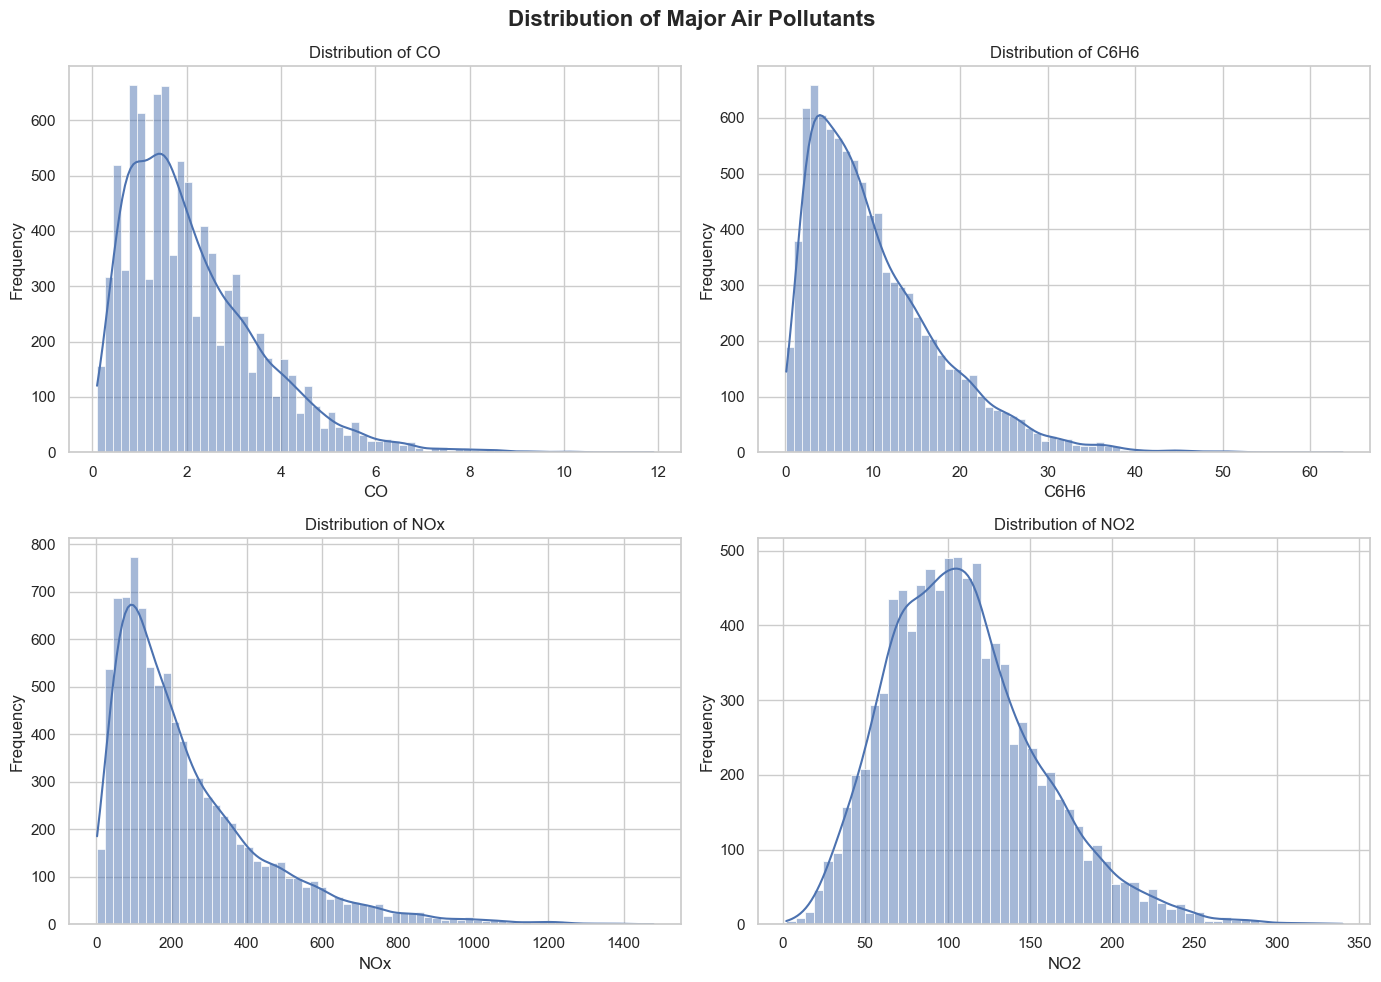

In [35]:
pollutants = ["CO", "C6H6", "NOx", "NO2"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, column in zip(axes.flatten(), pollutants):
    sns.histplot(
        df[column],
        kde=True,
        ax=ax
    )
    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Frequency")

plt.suptitle(
    "Distribution of Major Air Pollutants",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

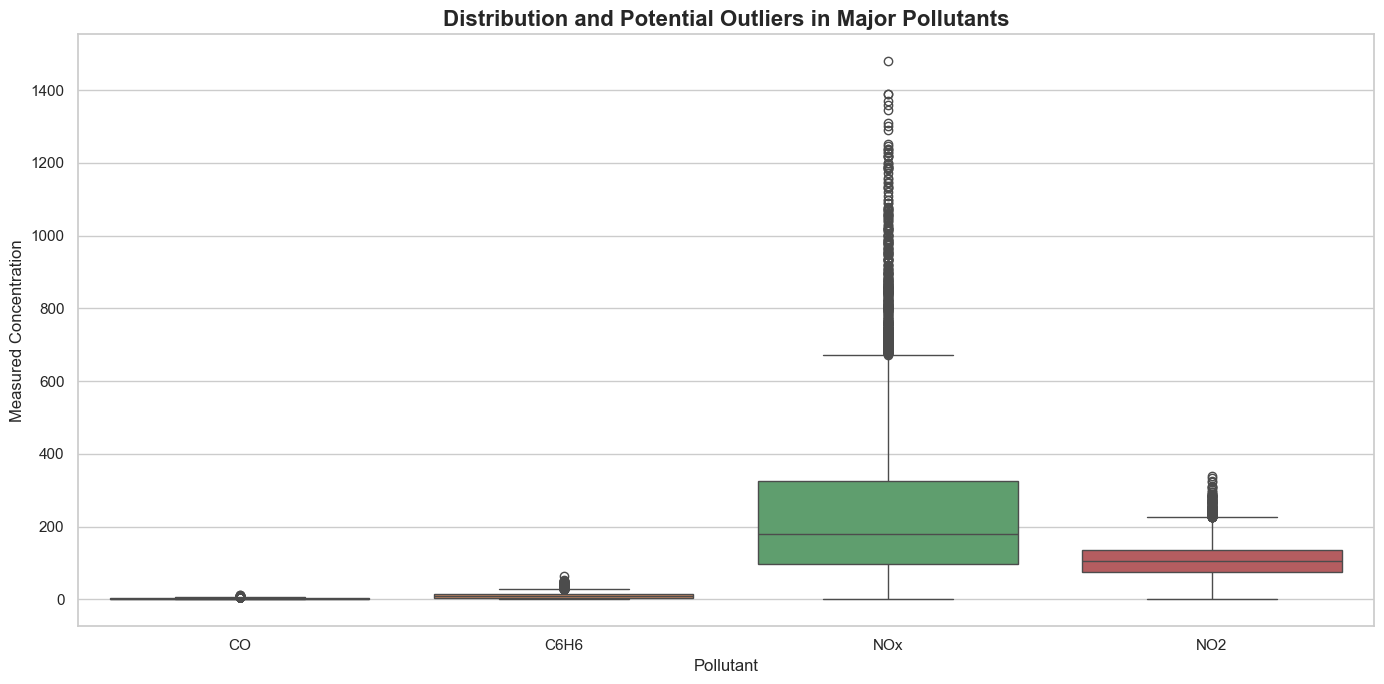

In [36]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df[pollutants]
)

plt.title(
    "Distribution and Potential Outliers in Major Pollutants",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Pollutant")
plt.ylabel("Measured Concentration")

plt.tight_layout()
plt.show()

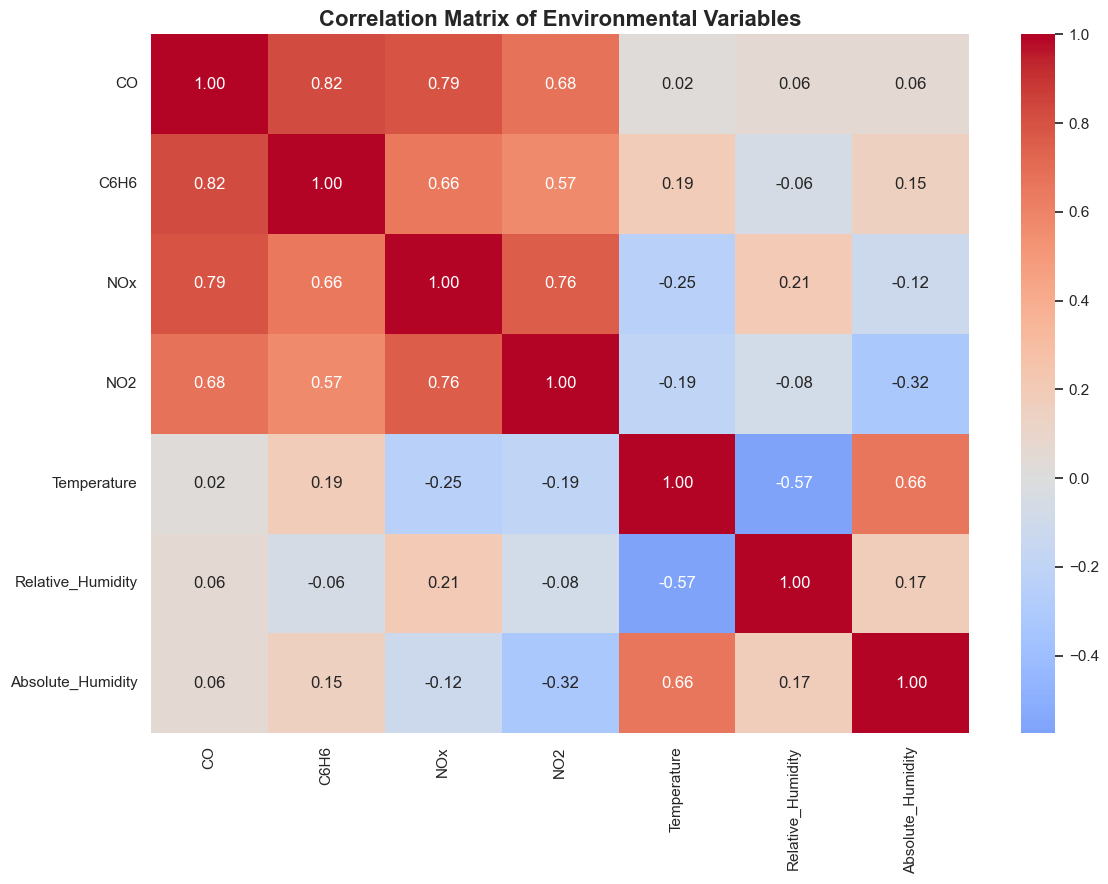

In [37]:
correlation_columns = [
    "CO",
    "C6H6",
    "NOx",
    "NO2",
    "Temperature",
    "Relative_Humidity",
    "Absolute_Humidity"
]

correlation_matrix = df[
    correlation_columns
].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Matrix of Environmental Variables",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

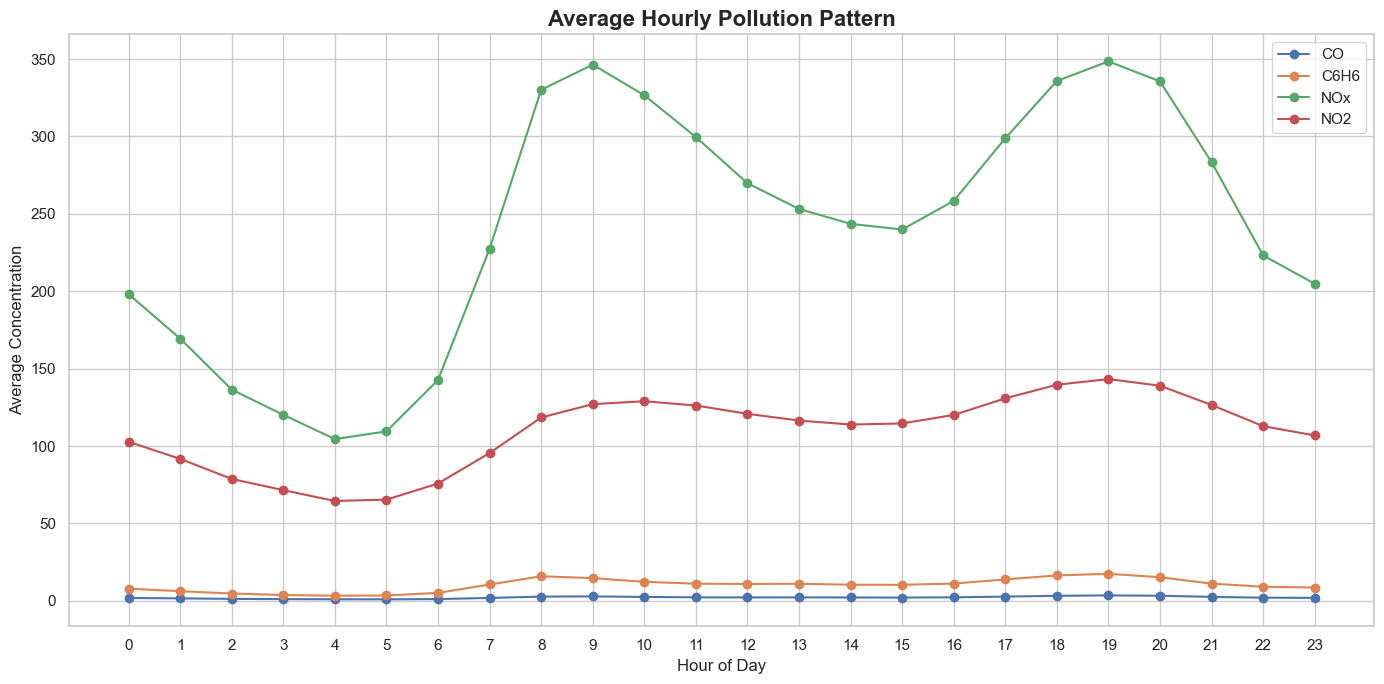

In [38]:
hourly_pollution = (
    df.groupby("Hour")[pollutants]
    .mean()
)

plt.figure(figsize=(14, 7))

for column in pollutants:
    plt.plot(
        hourly_pollution.index,
        hourly_pollution[column],
        marker="o",
        label=column
    )

plt.title(
    "Average Hourly Pollution Pattern",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Concentration")
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

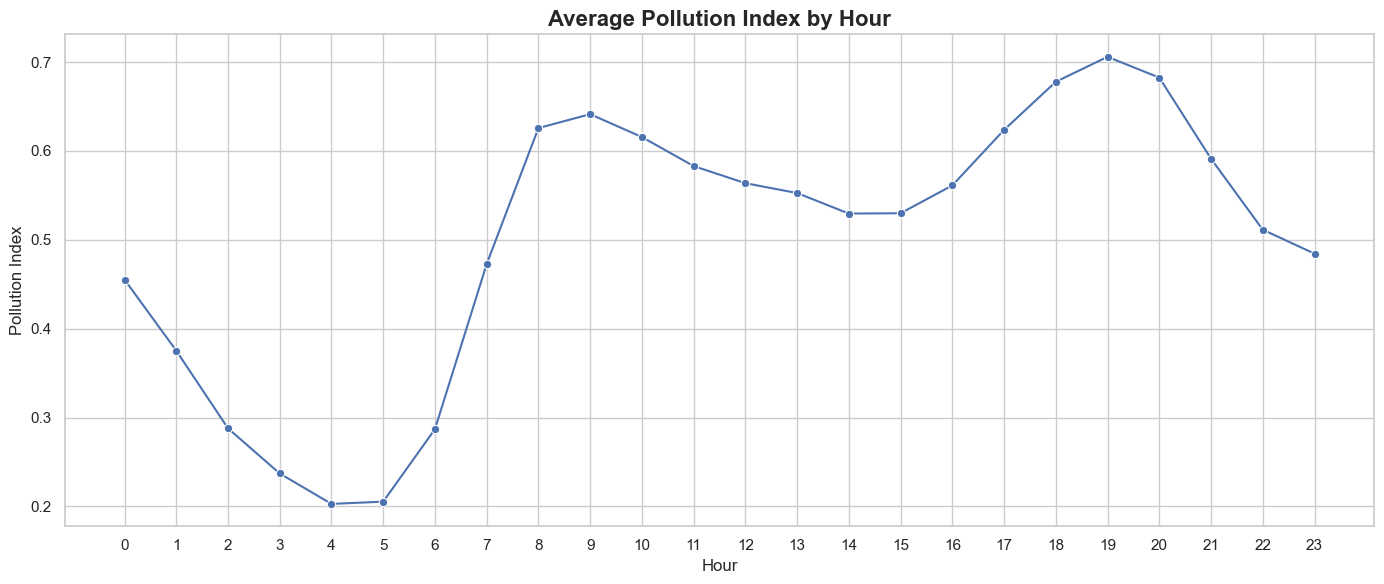

In [39]:
hourly_index = (
    df.groupby("Hour")["Pollution_Index"]
    .mean()
)

plt.figure(figsize=(14, 6))

sns.lineplot(
    x=hourly_index.index,
    y=hourly_index.values,
    marker="o"
)

plt.title(
    "Average Pollution Index by Hour",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Hour")
plt.ylabel("Pollution Index")
plt.xticks(range(24))

plt.tight_layout()
plt.show()

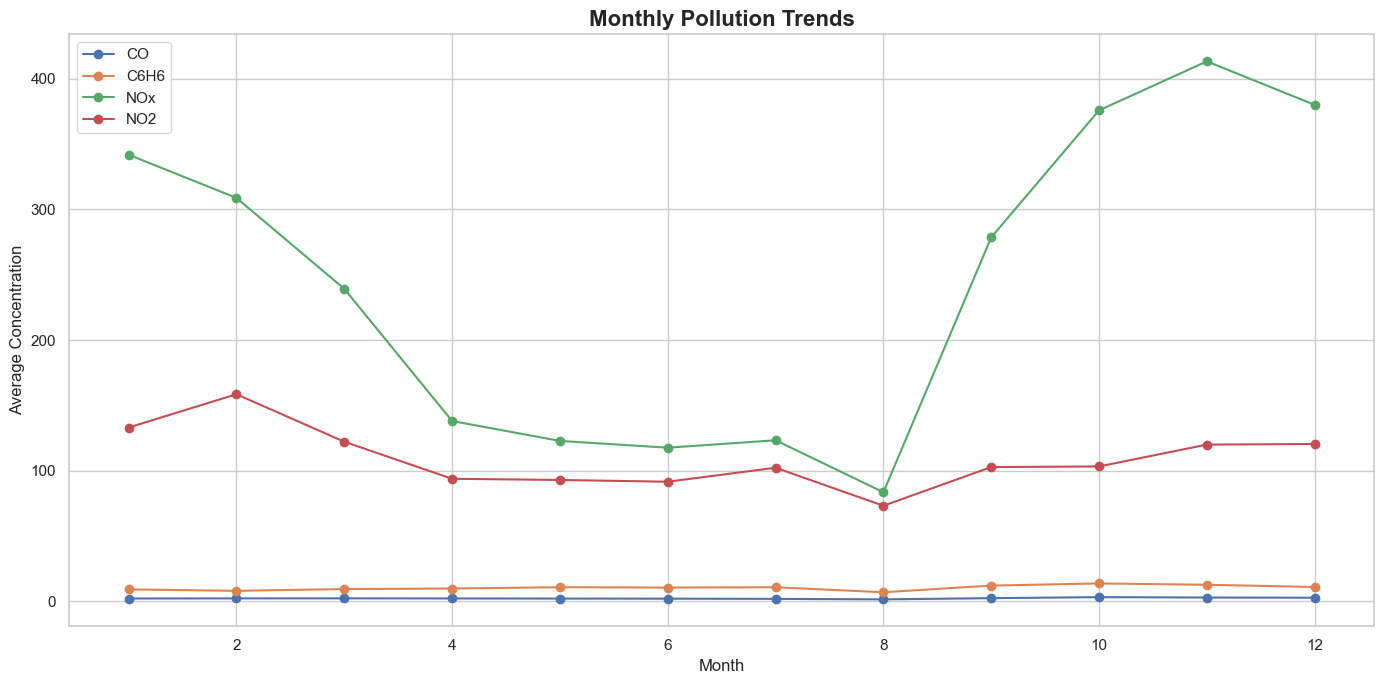

In [40]:
monthly_pollution = (
    df.groupby("Month")[pollutants]
    .mean()
)

plt.figure(figsize=(14, 7))

for column in pollutants:
    plt.plot(
        monthly_pollution.index,
        monthly_pollution[column],
        marker="o",
        label=column
    )

plt.title(
    "Monthly Pollution Trends",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Average Concentration")
plt.legend()

plt.tight_layout()
plt.show()

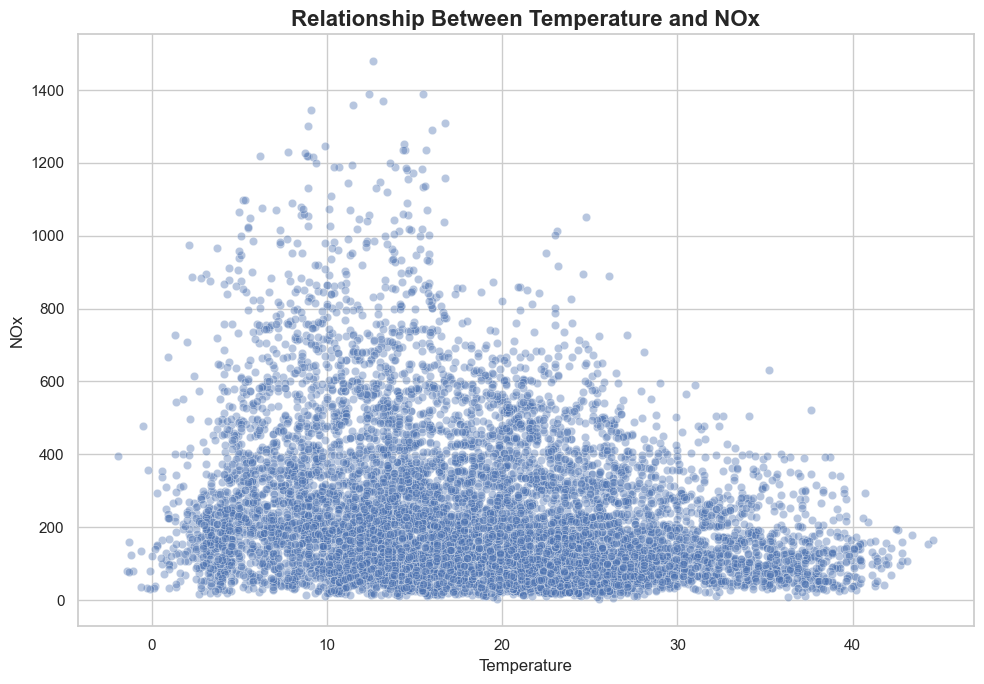

In [41]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="Temperature",
    y="NOx",
    alpha=0.4
)

plt.title(
    "Relationship Between Temperature and NOx",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Temperature")
plt.ylabel("NOx")

plt.tight_layout()
plt.show()

C:\Users\rohan bhowmik\AppData\Local\Temp\ipykernel_2096\1403925287.py:19: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\rohan bhowmik\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


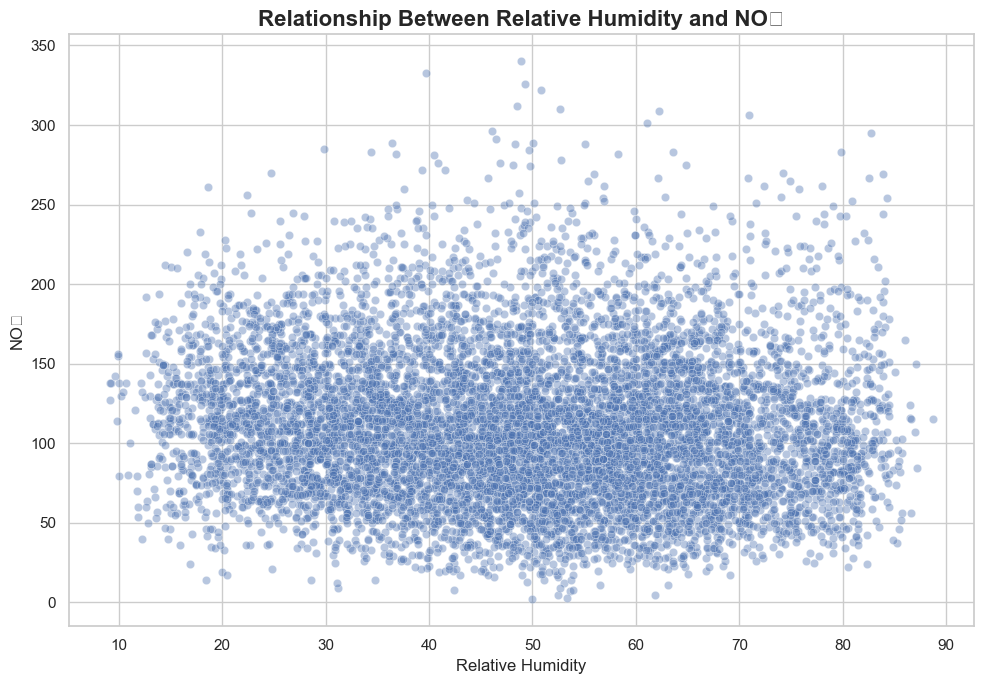

In [42]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="Relative_Humidity",
    y="NO2",
    alpha=0.4
)

plt.title(
    "Relationship Between Relative Humidity and NO₂",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Relative Humidity")
plt.ylabel("NO₂")

plt.tight_layout()
plt.show()

In [43]:
peak_analysis = (
    df.groupby("Is_Peak_Hour")[pollutants]
    .mean()
)

peak_analysis.index = [
    "Non-Peak Hours",
    "Peak Hours"
]

peak_analysis

,CO,C6H6,NOx,NO2
Non-Peak Hours,1.819762,8.254297,210.772568,102.205675
Peak Hours,2.885550,14.854110,317.576188,127.668847


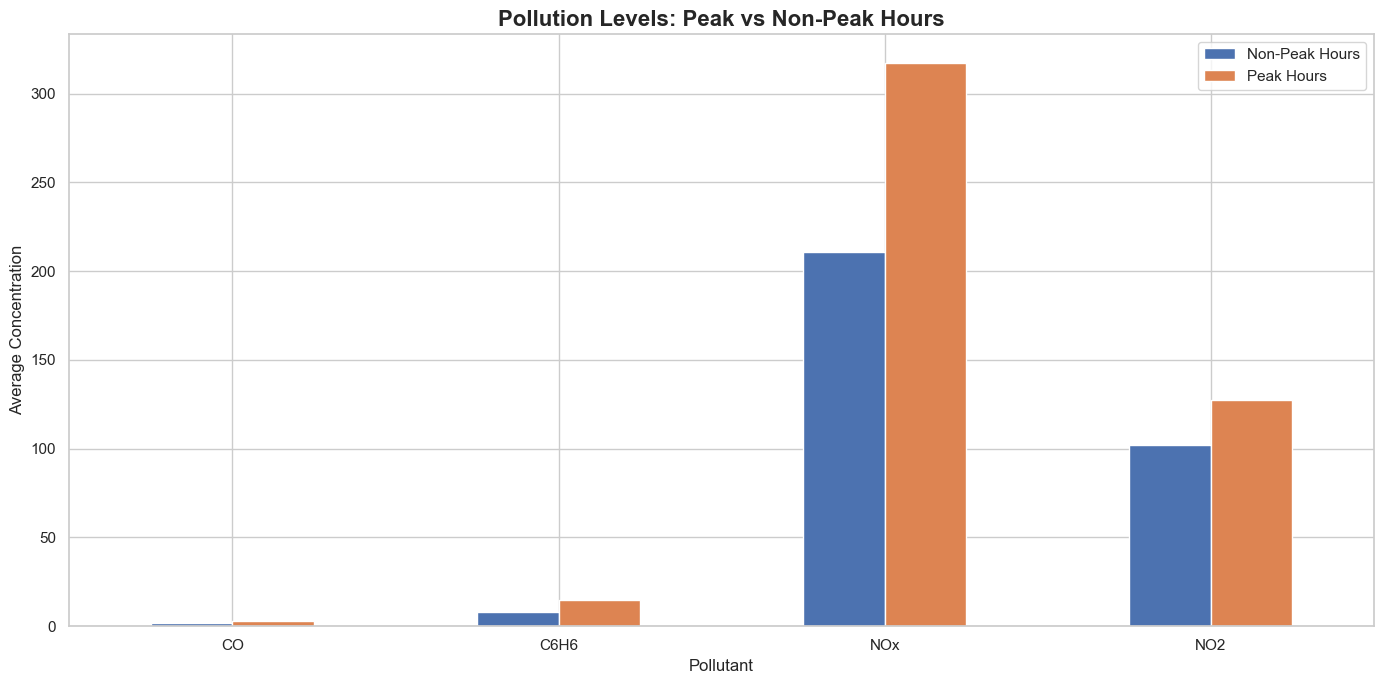

In [44]:
peak_analysis.T.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    "Pollution Levels: Peak vs Non-Peak Hours",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Pollutant")
plt.ylabel("Average Concentration")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

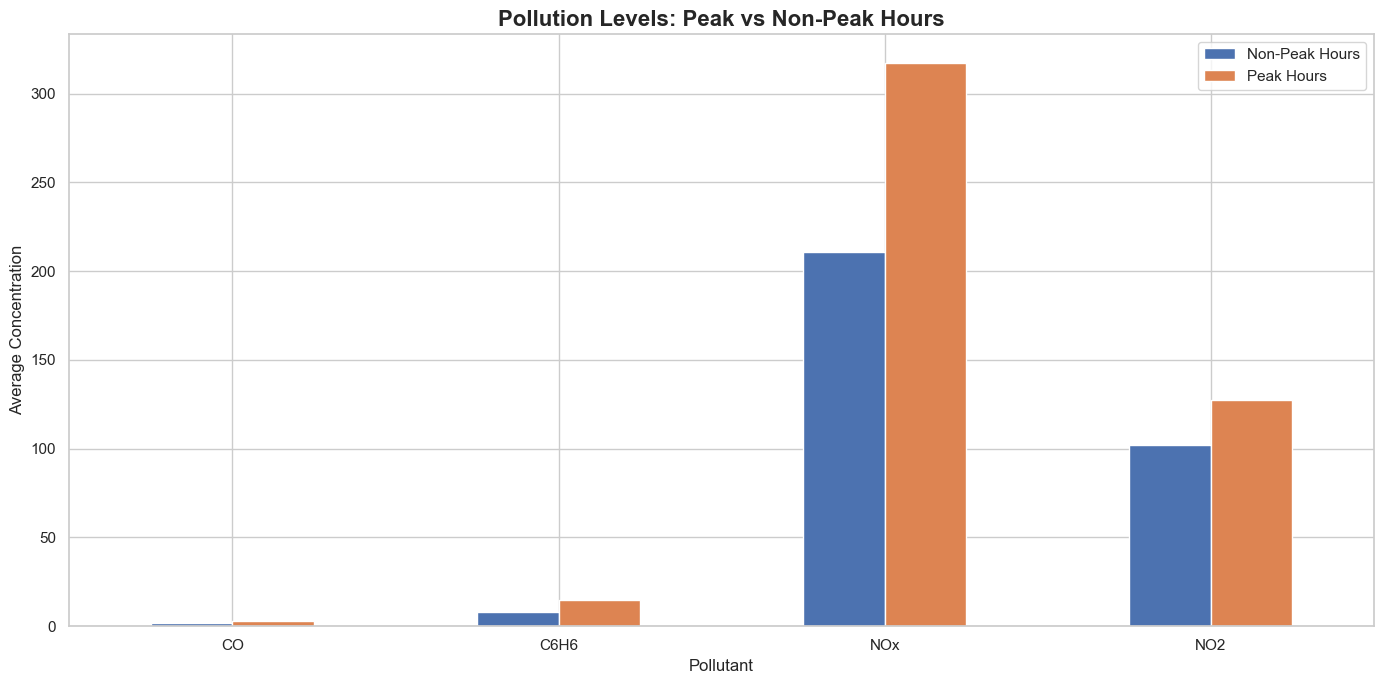

In [45]:
peak_analysis.T.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    "Pollution Levels: Peak vs Non-Peak Hours",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Pollutant")
plt.ylabel("Average Concentration")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
##  Statistical Analysis

To investigate whether pollution levels differ between peak and
non-peak periods, an independent two-sample statistical test is performed.

The analysis tests whether the observed difference in NOx concentrations
between the two groups is statistically significant.

In [47]:
peak_nox = df.loc[
    df["Is_Peak_Hour"] == 1,
    "NOx"
]

non_peak_nox = df.loc[
    df["Is_Peak_Hour"] == 0,
    "NOx"
]

t_stat, p_value = stats.ttest_ind(
    peak_nox,
    non_peak_nox,
    equal_var=False
)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

T-statistic: 21.5285
P-value: 0.000000


In [48]:
alpha = 0.05

if p_value < alpha:
    print(
        "Result: The difference in NOx levels between "
        "peak and non-peak periods is statistically significant."
    )
else:
    print(
        "Result: The observed difference in NOx levels "
        "is not statistically significant at the 5% level."
    )

Result: The difference in NOx levels between peak and non-peak periods is statistically significant.


In [ ]:
#  Machine Learning: NOx Prediction

### Objective

The machine-learning component predicts **NOx concentration** using
environmental conditions and related sensor measurements.

This transforms the project from descriptive analytics into predictive
data science.

### Target Variable

`NOx`

### Candidate Predictors

- CO
- C6H6
- NO2
- Temperature
- Relative Humidity
- Absolute Humidity
- Sensor measurements
- Hour
- Month
- Peak-hour indicator

In [50]:
features = [
    "CO",
    "C6H6",
    "NO2",
    "Temperature",
    "Relative_Humidity",
    "Absolute_Humidity",
    "PT08_S1_CO",
    "PT08_S2_NMHC",
    "PT08_S3_NOx",
    "PT08_S4_NO2",
    "PT08_S5_O3",
    "Hour",
    "Month",
    "Is_Weekend",
    "Is_Peak_Hour"
]

target = "NOx"

X = df[features]
y = df[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (9357, 15)
Target shape: (9357,)


In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 7485
Testing samples : 1872


In [54]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=150,
        random_state=42
    )
}

results = []
trained_models = {}

In [55]:
for name, model in models.items():

    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R² Score": r2
    })

    trained_models[name] = pipeline

results_df = pd.DataFrame(results)

results_df.sort_values(
    "R² Score",
    ascending=False
)

,Model,MAE,RMSE,R² Score
1,Random Forest,25.168799,41.756514,0.957733
2,Gradient Boosting,30.534579,46.803041,0.946899
0,Linear Regression,54.436751,75.529059,0.861713


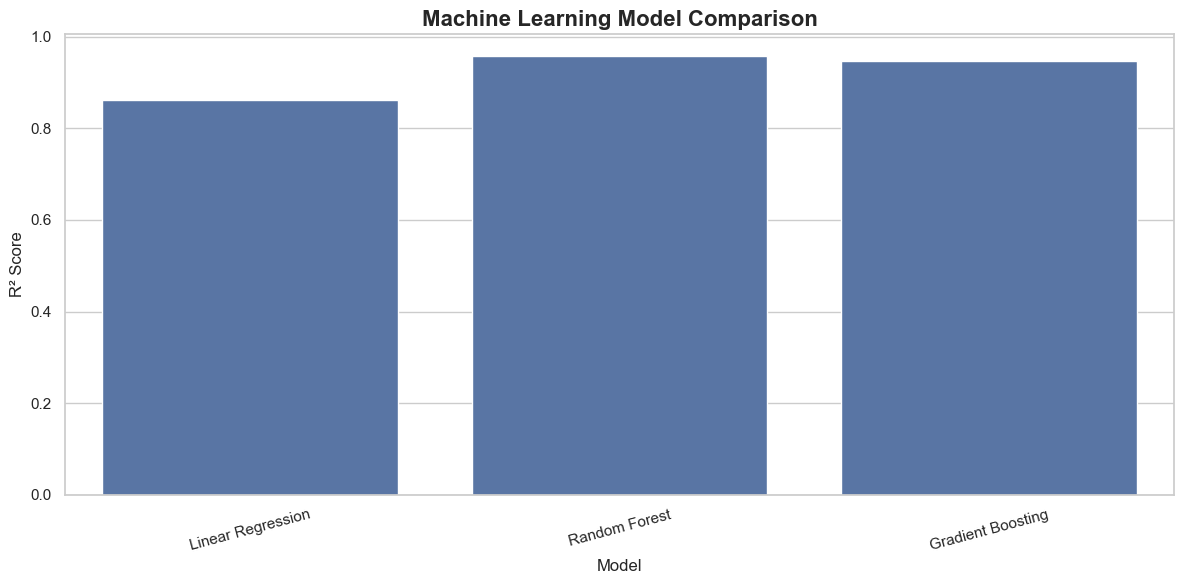

In [56]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="R² Score"
)

plt.title(
    "Machine Learning Model Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Model")
plt.ylabel("R² Score")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [57]:
best_model_name = (
    results_df
    .sort_values("R² Score", ascending=False)
    .iloc[0]["Model"]
)

best_model = trained_models[best_model_name]

print("Selected model:", best_model_name)

Selected model: Random Forest


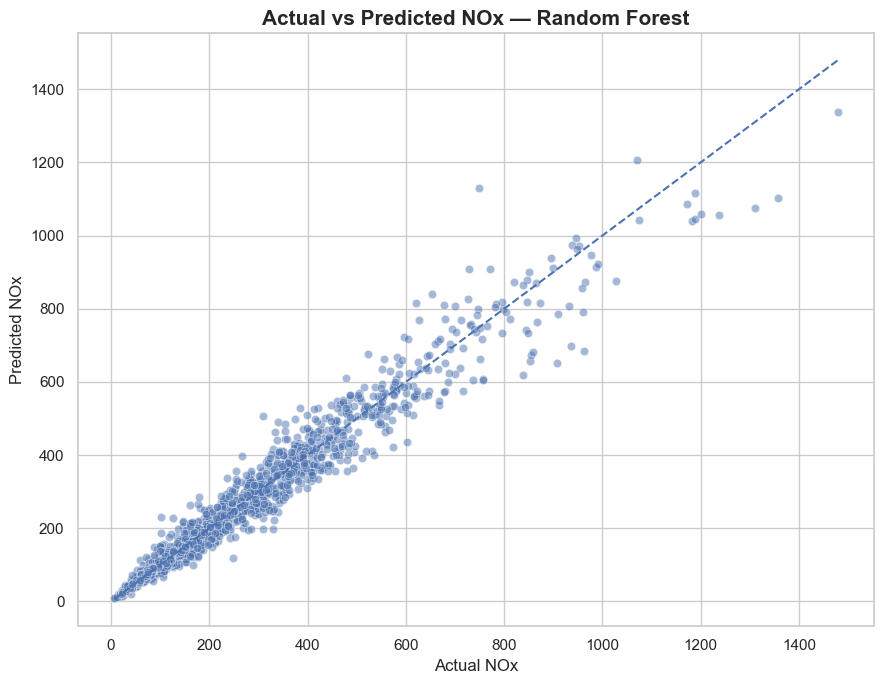

In [58]:
best_predictions = best_model.predict(X_test)

plt.figure(figsize=(9, 7))

sns.scatterplot(
    x=y_test,
    y=best_predictions,
    alpha=0.5
)

plt.xlabel("Actual NOx")
plt.ylabel("Predicted NOx")

plt.title(
    f"Actual vs Predicted NOx — {best_model_name}",
    fontsize=15,
    fontweight="bold"
)

# Reference line
min_value = min(y_test.min(), best_predictions.min())
max_value = max(y_test.max(), best_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.tight_layout()
plt.show()

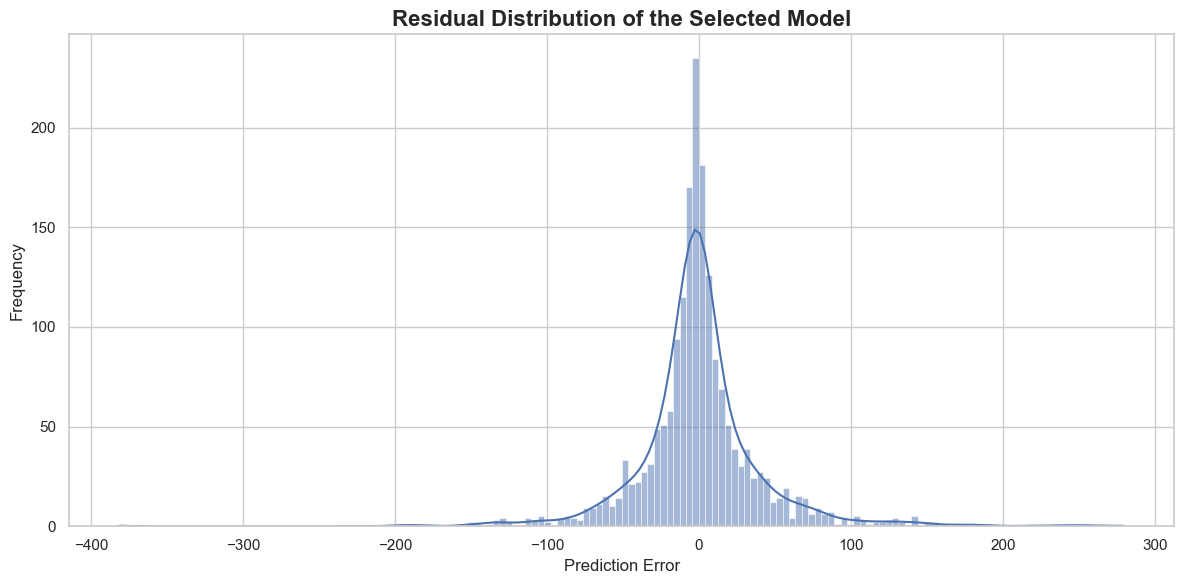

In [59]:
residuals = y_test - best_predictions

plt.figure(figsize=(12, 6))

sns.histplot(
    residuals,
    kde=True
)

plt.title(
    "Residual Distribution of the Selected Model",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [60]:
model_object = best_model.named_steps["model"]

if hasattr(model_object, "feature_importances_"):

    importance = pd.DataFrame({
        "Feature": features,
        "Importance": model_object.feature_importances_
    }).sort_values(
        "Importance",
        ascending=False
    )

    display(importance)

else:
    print(
        "The selected model does not provide "
        "tree-based feature importance."
    )

,Feature,Importance
0,CO,0.355863
8,PT08_S3_NOx,0.230090
2,NO2,0.187704
12,Month,0.092008
3,Temperature,0.037836
10,PT08_S5_O3,0.020594
9,PT08_S4_NO2,0.018209
4,Relative_Humidity,0.013368
7,PT08_S2_NMHC,0.012371
6,PT08_S1_CO,0.009205


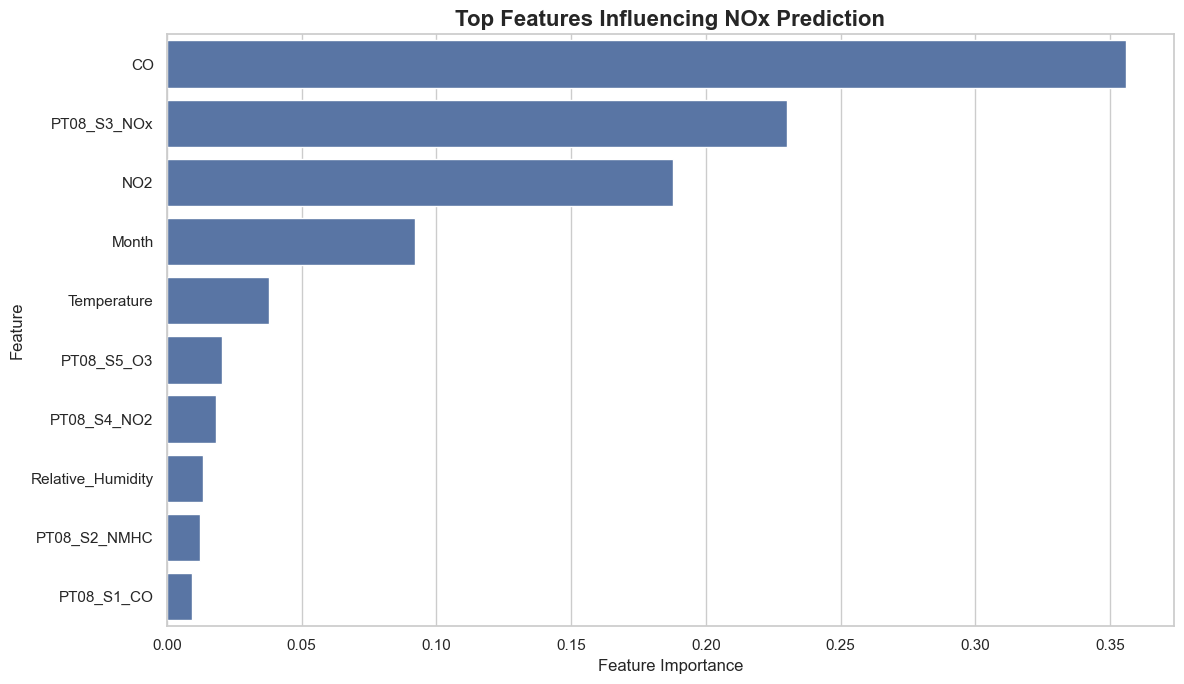

In [61]:
if hasattr(model_object, "feature_importances_"):

    plt.figure(figsize=(12, 7))

    sns.barplot(
        data=importance.head(10),
        x="Importance",
        y="Feature"
    )

    plt.title(
        "Top Features Influencing NOx Prediction",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")

    plt.tight_layout()
    plt.show()

In [ ]:
#  Key Data-Driven Insights

The following section summarizes the major findings discovered through
data cleaning, exploratory analysis, statistical testing, and machine
learning.

The conclusions should be written based on the actual numerical results
generated above rather than assumptions.

In [62]:
# Highest average pollutant
average_pollution = df[pollutants].mean().sort_values(
    ascending=False
)

print("Average pollutant levels:")
display(average_pollution.to_frame("Average Level"))

# Highest pollution hour
highest_pollution_hour = (
    df.groupby("Hour")["Pollution_Index"]
    .mean()
    .idxmax()
)

highest_pollution_value = (
    df.groupby("Hour")["Pollution_Index"]
    .mean()
    .max()
)

print(
    f"Highest average Pollution Index hour: "
    f"{highest_pollution_hour}:00 "
    f"({highest_pollution_value:.3f})"
)

Average pollutant levels:


,Average Level
NOx,241.922197
NO2,109.632094
C6H6,10.179155
CO,2.130603


Highest average Pollution Index hour: 19:00 (0.706)


In [ ]:
#  Strategic Recommendations

Based on the analysis, the following recommendations can be considered:

### 1. Peak-Hour Monitoring
Air-quality monitoring resources can be prioritized during periods
identified by the analysis as having elevated pollution levels.

### 2. Data-Driven Environmental Monitoring
Hourly sensor data can be continuously analyzed to identify changes
in pollution patterns rather than relying only on aggregated averages.

### 3. Predictive Pollution Monitoring
The machine-learning model demonstrates how historical environmental
and sensor variables can be used to estimate NOx concentrations.

### 4. Sensor-Based Decision Support
Important sensor variables identified by the model can help prioritize
which measurements deserve greater attention in future monitoring systems.

### 5. Temporal Analysis
Environmental authorities and researchers can use hourly and monthly
patterns to investigate recurring pollution behavior.

### 6. Future Real-Time System
The analytical workflow can be extended into a real-time dashboard that
accepts live sensor measurements and provides pollution forecasts,
alerts, and trend monitoring.

In [ ]:
#  Potential Impact

This project demonstrates how Data Science can support environmental
decision-making.

### Potential Applications

- Environmental monitoring
- Pollution forecasting
- Smart-city analytics
- Sensor anomaly detection
- Public-health research
- Traffic and emission studies
- Environmental policy research
- Real-time monitoring dashboards

The project also demonstrates an end-to-end Data Science workflow:
data acquisition, cleaning, exploratory analysis, statistical testing,
feature engineering, predictive modeling, evaluation, and interpretation.

In [ ]:
#  Limitations

1. The dataset represents a specific monitoring location and time period,
   so the findings should not automatically be generalized to all cities.

2. Sensor measurements may contain noise and calibration-related errors.

3. Missing measurements required preprocessing and interpolation.

4. The machine-learning model is based on historical observations and
   does not guarantee future real-world prediction accuracy.

5. Additional external variables such as traffic volume, wind speed,
   rainfall, industrial activity, and geographic information could
   improve future models.

6. The Pollution Index created in this project is an analytical feature,
   not an official regulatory air-quality index.

In [ ]:
#  Conclusion

This project presented a complete Data Science workflow for analyzing
real-world air-quality measurements using Python.

The analysis began with raw sensor data and progressed through data
quality assessment, missing-value treatment, feature engineering,
exploratory data analysis, statistical testing, and machine-learning
model development.

The project identified temporal and environmental patterns in pollutant
measurements and demonstrated how machine-learning techniques can be
used to predict NOx concentration from related environmental and sensor
variables.

Beyond prediction, the project highlights the value of Data Science as
a decision-support tool. The insights can contribute to environmental
monitoring, research, pollution management, and future smart-city
applications.

Overall, the project demonstrates an end-to-end approach to transforming
raw environmental data into meaningful analytical insights and
data-driven recommendations.

In [63]:
print("=" * 60)
print("AIR QUALITY DATA SCIENCE PROJECT — FINAL SUMMARY")
print("=" * 60)

print(f"Total observations : {len(df):,}")
print(f"Total features     : {df.shape[1]}")
print(f"Date range         : {df['DateTime'].min()} → {df['DateTime'].max()}")
print(f"Best ML model      : {best_model_name}")

best_result = results_df[
    results_df["Model"] == best_model_name
].iloc[0]

print(f"MAE                : {best_result['MAE']:.4f}")
print(f"RMSE               : {best_result['RMSE']:.4f}")
print(f"R² Score           : {best_result['R² Score']:.4f}")

print("=" * 60)
print("Project analysis completed successfully.")
print("=" * 60)

AIR QUALITY DATA SCIENCE PROJECT — FINAL SUMMARY
Total observations : 9,357
Total features     : 26
Date range         : 2004-03-10 18:00:00 → 2005-04-04 14:00:00
Best ML model      : Random Forest
MAE                : 25.1688
RMSE               : 41.7565
R² Score           : 0.9577
Project analysis completed successfully.


In [68]:
#  Final Model Performance & Export

import pandas as pd
from pathlib import Path

print("=" * 70)
print("FINAL MODEL PERFORMANCE")
print("=" * 70)

# Find the existing model results
if "results_df" in globals():
    final_performance = results_df.copy()

elif "model_results" in globals():
    final_performance = model_results.copy()

elif "results" in globals() and isinstance(results, pd.DataFrame):
    final_performance = results.copy()

else:
    # Automatically search for an existing DataFrame
    dataframe_candidates = []

    for name, obj in globals().items():
        if isinstance(obj, pd.DataFrame):
            columns_lower = [str(col).lower() for col in obj.columns]

            if any(
                metric in " ".join(columns_lower)
                for metric in ["r2", "rmse", "mae", "score", "model"]
            ):
                dataframe_candidates.append((name, obj))

    if dataframe_candidates:
        # Use the first matching model-results DataFrame
        source_name, final_performance = dataframe_candidates[0]
        final_performance = final_performance.copy()

        print(f"Using existing results DataFrame: {source_name}")

    else:
        raise NameError(
            "No model-results DataFrame was found. "
            "Please run the model evaluation cell before this cell."
        )

# Display final model performance
display(final_performance)

# Save results
documents_path = Path.home() / "Documents"

model_results_file = (
    documents_path / "Air_Quality_Model_Results.csv"
)

final_performance.to_csv(
    model_results_file,
    index=False
)

print("\n Model results saved successfully!")
print(f" Location: {model_results_file}")
print("=" * 70)

FINAL MODEL PERFORMANCE


,Model,MAE,RMSE,R² Score
0,Linear Regression,54.436751,75.529059,0.861713
1,Random Forest,25.168799,41.756514,0.957733
2,Gradient Boosting,30.534579,46.803041,0.946899



 Model results saved successfully!
 Location: C:\Users\rohan bhowmik\Documents\Air_Quality_Model_Results.csv


In [67]:
#  Project Completion Summary

print("\n" + "=" * 70)
print(" AIR QUALITY DATA SCIENCE PROJECT")
print("=" * 70)

print("\n Data loading completed")
print(" Data cleaning completed")
print(" Missing-value treatment completed")
print(" Feature engineering completed")
print(" Exploratory Data Analysis completed")
print(" Statistical analysis completed")
print(" Machine Learning completed")
print(" Model evaluation completed")
print(" Strategic recommendations generated")
print(" Final dataset exported")

print("\n Main Dataset:")
print("Air Quality Cleaned.csv")

print("\n Best Model:")
print(best_model_name)

print("\n Best R² Score:")
print(f"{best_result['R² Score']:.4f}")

print("\n Project Status: COMPLETED")
print("=" * 70)


 AIR QUALITY DATA SCIENCE PROJECT

 Data loading completed
 Data cleaning completed
 Missing-value treatment completed
 Feature engineering completed
 Exploratory Data Analysis completed
 Statistical analysis completed
 Machine Learning completed
 Model evaluation completed
 Strategic recommendations generated
 Final dataset exported

 Main Dataset:
Air Quality Cleaned.csv

 Best Model:
Random Forest

 Best R² Score:
0.9577

 Project Status: COMPLETED
